In [1]:
import pandas as pd
df = pd.read_csv('SPAM text message 20170820 - Data.csv')

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df['Category'] = df.Category.map({'ham':0, 'spam':1})

In [3]:
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['Message'], df['Category'], train_size = 0.8, random_state=1)

print('Number of rows in the total set: {}'.format(df.shape[0]))
print('Number of rows in the training set: {}'.format(X_train.shape[0]))
print('Number of rows in the test set: {}'.format(X_test.shape[0]))

Number of rows in the total set: 5572
Number of rows in the training set: 4457
Number of rows in the test set: 1115


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

count_vector = CountVectorizer()

training_data = count_vector.fit_transform(X_train)

testing_data = count_vector.transform(X_test)

# fit_transform() is used on the training data so that we can scale the training data 
# and also learn the scaling parameters of that data

In [7]:
training_data

<4457x7711 sparse matrix of type '<class 'numpy.int64'>'
	with 58978 stored elements in Compressed Sparse Row format>

In [8]:
from sklearn.naive_bayes import MultinomialNB
naive_bayes = MultinomialNB()
naive_bayes.fit(training_data,y_train)

MultinomialNB()

In [9]:
predictions = naive_bayes.predict(testing_data)

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Accuracy score: ', format(accuracy_score(y_test, predictions)))
print('Precision score: ', format(precision_score(y_test, predictions)))
print('Recall score: ', format(recall_score(y_test, predictions)))
print('F1 score: ', format(f1_score(y_test, predictions)))

Accuracy score:  0.989237668161435
Precision score:  0.9787234042553191
Recall score:  0.9387755102040817
F1 score:  0.9583333333333333


In [11]:
def clasification(df, train_size):
    X_train, X_test, y_train, y_test = train_test_split(df['Message'], df['Category'], train_size= train_size, random_state=42)
    count_vector = CountVectorizer()
    training_data = count_vector.fit_transform(X_train)
    testing_data = count_vector.transform(X_test)
    naive_bayes = MultinomialNB()
    naive_bayes.fit(training_data,y_train)
    predictions = naive_bayes.predict(testing_data)
    return accuracy_score(y_test, predictions)

In [12]:
results = []
train_set_sizes = [i/10 for i in range(1,10)]
for size in train_set_sizes:
    results.append(clasification(df,size))

Text(0, 0.5, 'accuracy')

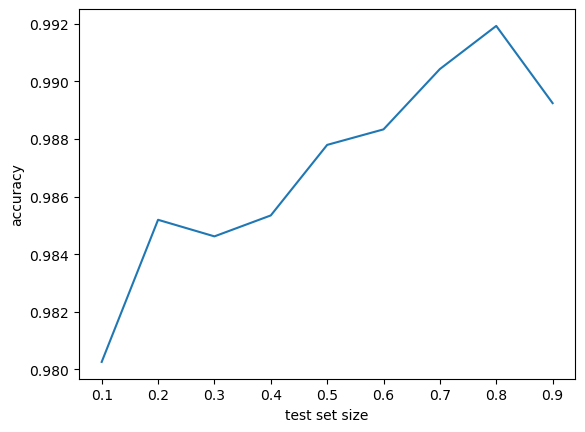

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_set_sizes, results)
plt.xlabel("test set size")
plt.ylabel("accuracy")